# Filtering of DEGs

In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import tqdm
import re

In [2]:
adata_aida = sc.read_h5ad(
    "/vol/data/dataset-similarity/raw/b0e547f0-462b-4f81-b31b-5b0a5d96f537.h5ad"
)
adata_aida

AnnData object with n_obs × n_vars = 1058909 × 36266
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Country', 'nCount_RNA', 'nFeature_RNA', 'Ethnicity_Selfreported', 'TCR_VDJdb', 'TCRa_V_gene', 'TCRa_D_gene', 'TCRa_J_gene', 'TCRa_C_gene', 'TCRb_V_gene', 'TCRb_D_gene', 'TCRb_J_gene', 'TCRb_C_gene', 'TCR_Clonality', 'TCR_Clone_ID', 'BCR_VDJ_V_call', 'BCR_VDJ_D_ca

In [3]:
avg_counts = {}
nnz_fraction = {}

X = adata_aida.raw.X.tocsc()
for gene in tqdm.tqdm(adata_aida.var.feature_name):
    x = X[:, adata_aida.var.feature_name == gene].toarray()
    avg_counts[gene] = np.mean(x)
    nnz_fraction[gene] = np.mean(x > 0.)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36266/36266 [02:13<00:00, 272.31it/s]


In [4]:
def add_expression_info(df):
    return (
        df.assign(
            avg_counts=lambda df: df["Approved symbol"].replace(avg_counts).apply(lambda x: np.nan if isinstance(x, str) else x),
            nnz_fraction=lambda df: df["Approved symbol"].replace(nnz_fraction).apply(lambda x: np.nan if isinstance(x, str) else x)
        )
        .sort_values("avg_counts", ascending=False)
    )


def merge_gene_symbols(gene_df):
    gene_symbol = gene_df["Approved symbol"].tolist()
    origin = ["Approved symbol"] * len(gene_symbol)
    
    for col in ["Alias symbols", "Previous symbols"]:
        for elem in gene_df[col].dropna():
            symbols = elem.split(", ")
            gene_symbol += symbols
            origin += [col] * len(symbols)

    return pd.DataFrame({
        "Approved symbol": gene_symbol,
        "origin": origin
    })


In [5]:
gene_table = pd.read_csv("hgnc_genenames.tsv", sep="\t")

In [6]:
pseudogenes = gene_table.query("`Locus type` == 'pseudogene'")

In [7]:
mt_chromosome_genes = pd.read_csv("hgnc_mitochondria.tsv", sep="\t")

## Gene filters

### Mitochondrial genes

In [8]:
mt_genes = pd.concat([
    gene_table.loc[
        gene_table["Gene group name"].str.contains("mitochondria", na=False)
    ],
    mt_chromosome_genes
])
print(f"Filter removes {len(mt_genes)} genes")
mt_genes[["Approved symbol"]].pipe(add_expression_info).head(25)

Filter removes 178 genes


,Approved symbol,avg_counts,nnz_fraction
4,MT-CO1,47.105072,0.999438
5,MT-CO2,30.356342,0.999215
6,MT-CO3,23.005434,0.998420
10,MT-CYB,18.888977,0.996189
1,MT-ATP6,15.647953,0.995934
20,MT-ND4L,10.848419,0.977476
16,MT-ND1,10.825024,0.990801
21,MT-ND5,10.311006,0.987734
18,MT-ND3,9.971279,0.984843
19,MT-ND4,9.484069,0.987679


In [9]:
mt_pseudogenes = pseudogenes.loc[
    pseudogenes["Approved name"].str.contains(
        "|".join(mt_genes["Approved symbol"].tolist())
    ) |
    pseudogenes["Approved name"].str.contains(
        "|".join(mt_genes["Approved name"].tolist())
    )
]
print(f"Filter removes {len(mt_pseudogenes)} genes")
mt_pseudogenes[["Approved symbol"]].pipe(add_expression_info).head(15)

/tmp/ipykernel_773663/1644827795.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pseudogenes["Approved name"].str.contains(


Filter removes 602 genes


,Approved symbol,avg_counts,nnz_fraction
21850,MTRNR2L12,0.018614,0.018151
21846,MTRNR2L8,0.003508,0.003482
21839,MTRNR2L1,0.002341,0.002335
21844,MTRNR2L6,0.000421,0.000420
21843,MTRNR2L5,0.000302,0.000302
21849,MTRNR2L11,0.000292,0.000292
21842,MTRNR2L4,0.000272,0.000271
21848,MTRNR2L10,0.000105,0.000105
21851,MTRNR2L13,0.000094,0.000093
21841,MTRNR2L3,0.000089,0.000089


In [10]:
mitochondrial = (    
    pd.concat([
        merge_gene_symbols(mt_genes),
        merge_gene_symbols(mt_pseudogenes)
    ])
)

mitochondrial.pipe(add_expression_info).head(30)

,Approved symbol,origin,avg_counts,nnz_fraction
126,MT-CO1,Approved symbol,47.105072,0.999438
373,RPS12,Alias symbols,47.031776,0.992028
236,RPL13,Alias symbols,41.963284,0.992365
127,MT-CO2,Approved symbol,30.356342,0.999215
128,MT-CO3,Approved symbol,23.005434,0.998420
132,MT-CYB,Approved symbol,18.888977,0.996189
123,MT-ATP6,Approved symbol,15.647953,0.995934
142,MT-ND4L,Approved symbol,10.848419,0.977476
138,MT-ND1,Approved symbol,10.825024,0.990801
143,MT-ND5,Approved symbol,10.311006,0.987734


### Ribosomal genes

In [11]:
ribosomal_genes = gene_table.loc[
    gene_table["Gene group name"].str.contains("ribosomal|Ribosomal", na=False) |
    gene_table["Approved symbol"].isin(["RPL17-C18orf32", "RPL17P52", "RPL36A-HNRNPH2", "RPS10-NUDT3"])
]
print(f"Filter removes {len(ribosomal_genes)} genes")

Filter removes 276 genes


In [12]:
# ribosomal_genes = gene_table.loc[
#     gene_table["Locus type"].str.contains("ribosomal", na=False)
# ]
# print(f"Filter removes {len(ribosomal_genes)} genes")

In [13]:
ribosomal_pseudogenes = pseudogenes.loc[
    pseudogenes["Approved name"].str.contains(
        "|".join(ribosomal_genes["Approved name"].tolist())
    ) | 
    pseudogenes["Approved name"].str.contains(
        "|".join(ribosomal_genes["Approved symbol"].tolist())
    ) |
    pseudogenes["Approved name"].str.contains("ribosomal")
]
print(f"Filter removes {len(ribosomal_pseudogenes)} genes")

Filter removes 2692 genes


/tmp/ipykernel_773663/1338863977.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pseudogenes["Approved name"].str.contains(


In [14]:
ribosomal = (    
    pd.concat([
        merge_gene_symbols(ribosomal_genes),
        merge_gene_symbols(ribosomal_pseudogenes)
    ])
)

ribosomal.pipe(add_expression_info).head(30)

,Approved symbol,origin,avg_counts,nnz_fraction
174,RPL10,Approved symbol,48.706585,0.993751
644,RPL10,Alias symbols,48.706585,0.993751
218,RPLP1,Approved symbol,47.918938,0.994967
499,RPS12,Alias symbols,47.031776,0.992028
234,RPS12,Approved symbol,47.031776,0.992028
216,RPL41,Approved symbol,42.517963,0.993504
348,RPL13,Alias symbols,41.963284,0.992365
179,RPL13,Approved symbol,41.963284,0.992365
249,RPS27,Approved symbol,41.126633,0.990688
203,RPL32,Approved symbol,35.476749,0.990066


### IncRNA / long non-coding RNA

In [15]:
incrna_genes = gene_table.loc[
    gene_table["Locus type"].str.contains("RNA, long non-coding", na=False)
]
print(f"Filter removes {len(incrna_genes)} genes")

incrna_genes[["Approved symbol"]].pipe(add_expression_info).head(25)

Filter removes 5780 genes


,Approved symbol,avg_counts,nnz_fraction
17920,MALAT1,117.340065,0.996413
22500,NEAT1,4.989398,0.717165
36306,SNHG29,2.715686,0.822109
10041,GAS5,2.305990,0.746994
42902,ZFAS1,1.967402,0.768965
24997,PCED1B-AS1,1.877490,0.631683
36286,SNHG6,1.807708,0.759270
4536,CHASERR,1.792994,0.720034
36285,SNHG5,1.207095,0.606947
36288,SNHG8,1.165647,0.577368


In [16]:
incrna_pseudogenes = pseudogenes.loc[
    pseudogenes["Approved name"].str.contains(
        "|".join(incrna_genes["Approved symbol"].tolist())
    ) | 
    pseudogenes["Approved name"].str.contains(
        "|".join(incrna_genes["Approved name"].tolist())
    )
]
print(f"Filter removes {len(incrna_pseudogenes)} genes")

incrna_pseudogenes[["Approved symbol"]].pipe(add_expression_info).head(25)

/tmp/ipykernel_773663/1947120145.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pseudogenes["Approved name"].str.contains(


Filter removes 327 genes


,Approved symbol,avg_counts,nnz_fraction
2360,BCYRN1P1,NaN,NaN
2361,BCYRN1P2,NaN,NaN
2362,BCYRN1P3,NaN,NaN
11410,HCG4P1,NaN,NaN
11411,HCG4P2,NaN,NaN
11412,HCG4P3,NaN,NaN
11413,HCG4P4,NaN,NaN
11414,HCG4P5,NaN,NaN
11415,HCG4P7,NaN,NaN
11416,HCG4P8,NaN,NaN


In [17]:
incrna = (    
    pd.concat([
        merge_gene_symbols(incrna_genes),
        merge_gene_symbols(incrna_pseudogenes)
    ])
)

incrna.pipe(add_expression_info).head(30)

,Approved symbol,origin,avg_counts,nnz_fraction
4033,MALAT1,Approved symbol,117.340065,0.996413
4337,NEAT1,Approved symbol,4.989398,0.717165
5128,SNHG29,Approved symbol,2.715686,0.822109
1090,GAS5,Approved symbol,2.305990,0.746994
5677,ZFAS1,Approved symbol,1.967402,0.768965
4520,PCED1B-AS1,Approved symbol,1.877490,0.631683
5108,SNHG6,Approved symbol,1.807708,0.759270
467,CHASERR,Approved symbol,1.792994,0.720034
5107,SNHG5,Approved symbol,1.207095,0.606947
5110,SNHG8,Approved symbol,1.165647,0.577368


### TCR genes

In [18]:
# !wget https://raw.githubusercontent.com/nealpsmith/neals_python_functions/refs/heads/master/neals_python_functions/analysis/db/tcr_genes.tsv

In [19]:
tcr_data = (
    pd.read_csv("tcr_genes.tsv", sep="\t")
    [["Approved symbol", "Approved name"]]
    # TRAV1-2 -> MAIT marker; TRGV9 and TRDV2 -> circulating gdT
    .query("`Approved symbol` not in ['TRAV1-2', 'TRGV9', 'TRDV2']")
)
tcr_genes = [
    gene
    for gene, name 
    in zip(tcr_data["Approved symbol"], tcr_data["Approved name"]) 
    if any(re.findall("variable|joining|diversity", name))
]
tcr_genes = pd.DataFrame({"Approved symbol": tcr_genes, "origin": "Approved symbol"})

tcr_genes.pipe(add_expression_info).head(25)

,Approved symbol,origin,avg_counts,nnz_fraction
173,TRBV20-1,Approved symbol,0.491227,0.052123
149,TRBV7-9,Approved symbol,0.320709,0.029528
206,TRBV5-1,Approved symbol,0.315698,0.032998
141,TRBV7-2,Approved symbol,0.275025,0.020114
182,TRBV28,Approved symbol,0.263856,0.035791
172,TRBV19,Approved symbol,0.257350,0.032512
155,TRBV3-1,Approved symbol,0.193686,0.020836
144,TRBV2,Approved symbol,0.167736,0.022495
177,TRBV4-1,Approved symbol,0.163031,0.015694
152,TRBV9,Approved symbol,0.162191,0.023753


### BCR genes

In [20]:
# !wget https://raw.githubusercontent.com/nealpsmith/neals_python_functions/refs/heads/master/neals_python_functions/analysis/db/bcr_genes.tsv

In [21]:
bcr_data = pd.read_csv("bcr_genes.tsv", sep="\t")[["Approved symbol", "Approved name"]]
bcr_genes = [
    gene
    for gene, name 
    in zip(bcr_data["Approved symbol"], bcr_data["Approved name"]) 
    if any(re.findall("variable|joining|diversity", name))
]
bcr_genes = pd.DataFrame({"Approved symbol": bcr_genes, "origin": "Approved symbol"})

bcr_genes.pipe(add_expression_info).head(25)

,Approved symbol,origin,avg_counts,nnz_fraction
299,IGKV3-20,Approved symbol,1.707948,0.036452
328,IGLV2-14,Approved symbol,1.291502,0.045231
298,IGKV4-1,Approved symbol,1.182920,0.027811
250,IGKV1-5,Approved symbol,1.110712,0.023317
146,IGHV3-23,Approved symbol,1.022697,0.023032
296,IGKV3-15,Approved symbol,0.890406,0.019115
294,IGKV3-11,Approved symbol,0.829781,0.019914
368,IGLV1-44,Approved symbol,0.743807,0.019428
149,IGHV3-30,Approved symbol,0.639503,0.016124
200,IGHV4-39,Approved symbol,0.616784,0.015361


## Combine genes to filter and save

In [22]:
genes_to_filter = pd.concat([
    mitochondrial.assign(filter_type="mitochondrial"),
    ribosomal.assign(filter_type="ribosomal"),
    incrna.assign(filter_type="IncRNA"),
    tcr_genes.assign(filter_type="TCR"),
    bcr_genes.assign(filter_type="BCR"),
]).drop_duplicates("Approved symbol")

(
    genes_to_filter
    .rename(columns={"Approved symbol": "feature_name"})
    .to_csv("filtered-genes.csv", index=False)
)

## Create list of offical gene symbols based on genenames.org

In [23]:
offical_gene_symbols = (
    merge_gene_symbols(gene_table)
    .drop_duplicates()
    .rename(columns={"Approved symbol": "feature_name"})
)
offical_gene_symbols

,feature_name,origin
0,A1BG,Approved symbol
1,A1BG-AS1,Approved symbol
2,A1CF,Approved symbol
3,A2M,Approved symbol
4,A2M-AS1,Approved symbol
...,...,...
103593,KIAA0913,Previous symbols
103594,C19orf68,Previous symbols
103595,C6orf113,Previous symbols
103596,ZUFSP,Previous symbols


In [24]:
offical_gene_symbols.to_csv("official-genes.csv", index=False)

## Summary statistics

In [25]:
genes_to_filter.query(f"`Approved symbol` in {gene_table['Approved symbol'].tolist()}")

,Approved symbol,origin,filter_type
0,AURKAIP1,Approved symbol,mitochondrial
1,CHCHD1,Approved symbol,mitochondrial
2,FASTK,Approved symbol,mitochondrial
3,FASTKD1,Approved symbol,mitochondrial
4,FASTKD2,Approved symbol,mitochondrial
...,...,...,...
401,IGLV1-51,Approved symbol,BCR
402,IGLJ5,Approved symbol,BCR
403,IGLJ6,Approved symbol,BCR
404,IGLJ7,Approved symbol,BCR


In [26]:
len(gene_table)

43812

In [27]:
genes_to_filter.pipe(add_expression_info).head(30)

,Approved symbol,origin,filter_type,avg_counts,nnz_fraction
4033,MALAT1,Approved symbol,IncRNA,117.340065,0.996413
174,RPL10,Approved symbol,ribosomal,48.706585,0.993751
218,RPLP1,Approved symbol,ribosomal,47.918938,0.994967
126,MT-CO1,Approved symbol,mitochondrial,47.105072,0.999438
373,RPS12,Alias symbols,mitochondrial,47.031776,0.992028
216,RPL41,Approved symbol,ribosomal,42.517963,0.993504
236,RPL13,Alias symbols,mitochondrial,41.963284,0.992365
249,RPS27,Approved symbol,ribosomal,41.126633,0.990688
203,RPL32,Approved symbol,ribosomal,35.476749,0.990066
199,RPL28,Approved symbol,ribosomal,35.196445,0.991287


<Axes: xlabel='Locus type'>

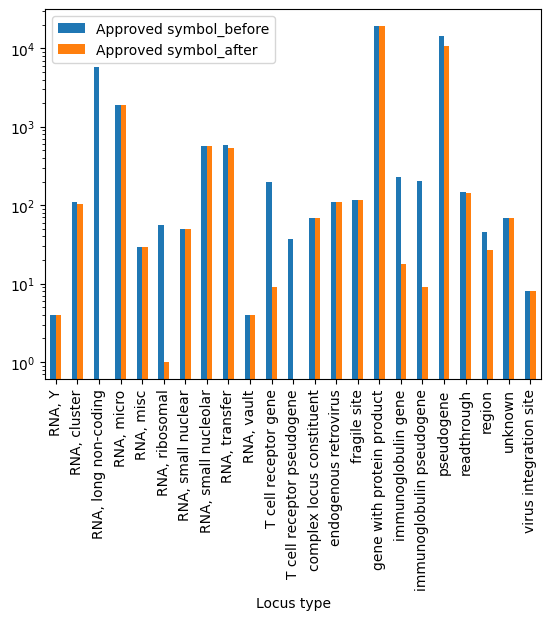

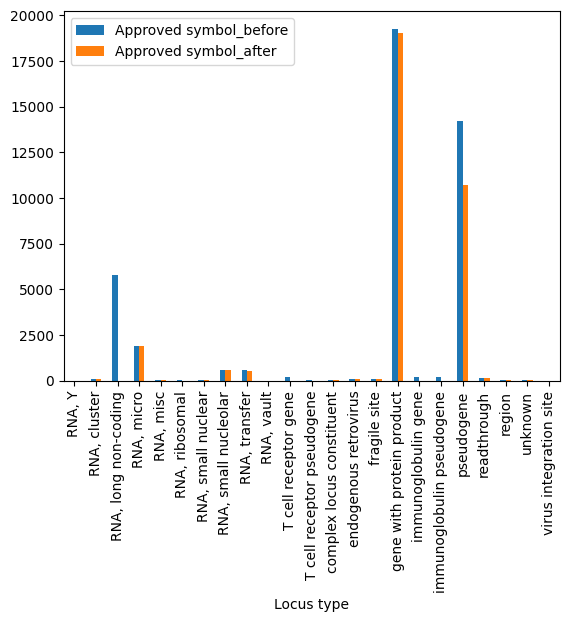

In [28]:
freq_before = gene_table.groupby("Locus type")["Approved symbol"].count()
freq_after = gene_table[
    ~gene_table["Approved symbol"].isin(genes_to_filter["Approved symbol"].tolist())
].groupby("Locus type")["Approved symbol"].count()

before_after_comparision = pd.merge(
    freq_before.to_frame(),
    freq_after.to_frame(),
    how="outer",
    left_index=True,
    right_index=True,
    suffixes=("_before", "_after")
).fillna(0)

before_after_comparision.plot(kind="bar", logy=True)
before_after_comparision.plot(kind="bar", logy=False)